# Comparaison Experts (Steam) vs Folksonomy (Joueurs)

## Objectif
S'appuyer sur **Lu et al. (2010)** pour comparer les métadonnées officielles de Steam (Genres et Catégories fournis par les développeurs) avec les tags utilisateurs.

Cette analyse permet de voir si les utilisateurs apportent une valeur ajoutée (granularité) ou s'ils se contentent de répéter les catégories officielles.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

db_path = '../data/2024-12-13.steam.db'
conn = sqlite3.connect(db_path)

# 1. Extraction des Genres Experts
query_genres = """
SELECT g.id, g.name, gr.label as expert_genre
FROM games g
JOIN game_genre gg ON g.id = gg.game_id
JOIN genres gr ON gg.genre_id = gr.id
"""
df_expert_genres = pd.read_sql_query(query_genres, conn)

# 2. Extraction des Catégories Experts (ex: Multi-player, Steam Achievements)
query_cats = """
SELECT g.id, c.label as expert_category
FROM games g
JOIN game_category gc ON g.id = gc.game_id
JOIN categories c ON gc.category_id = c.id
"""

try:
    df_expert_cats = pd.read_sql_query(query_cats, conn)
except:
    df_expert_cats = pd.DataFrame(columns=['id', 'label'])

conn.close()

# Chargement de notre base folksonomique structurée pour comparer
df_folk = pd.read_csv('../data/Games_Gameplay_Taxonomy.csv')

print(f"Données experts chargées. Nombre de jeux avec genres officiels : {df_expert_genres['id'].nunique()}")

Données experts chargées. Nombre de jeux avec genres officiels : 112332


*On a 112332 jeux avec un genre officiels.*

## 1. Analyse Quantitative : Richesse de l'information

Comparons le nombre moyen de labels par jeu entre experts et joueurs.

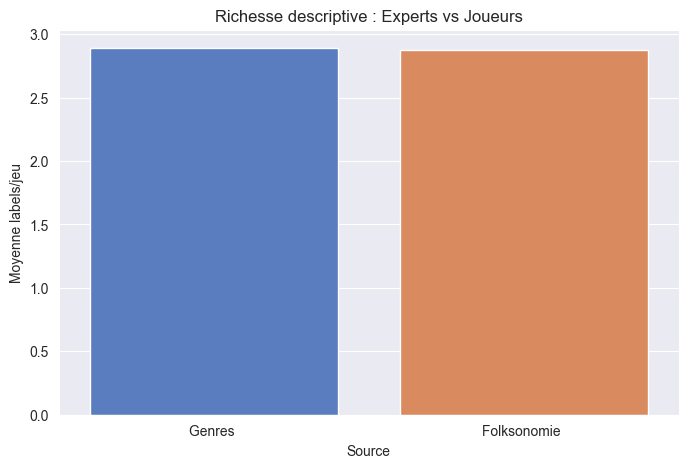

In [3]:
expert_counts = df_expert_genres.groupby('id').size()
folk_counts = df_folk.set_index('game_id')[['Genre', 'Mechanics', 'Theme', 'Mood']].notna().sum(axis=1)

stats = pd.DataFrame({
    'Source': ['Genres ', 'Folksonomie '],
    'Moyenne labels/jeu': [expert_counts.mean(), folk_counts.mean()]
})

plt.figure(figsize=(8, 5))
# Correction du warning Seaborn : on assigne x à hue et on désactive la légende
sns.barplot(data=stats, x='Source', y='Moyenne labels/jeu', hue='Source', palette='muted', legend=False)
plt.title("Richesse descriptive : Experts vs Joueurs")
plt.show()

## 2. Analyse de l'Accord (Consensus) pour tous les genres

Analyse comparative pour chaque genre officiel : quel pourcentage est aussi confirmé par les joueurs ?

**Note importante** : Seuls les genres présents dans la folksonomie (basée sur le gameplay) sont analysés.
Les genres officiels qui n'existent pas dans la folksonomie (éléments marketing, distribution, statut de développement)
sont exclus car ils n'ont pas d'équivalent pertinent pour cette analyse de consensus.

Genres uniques présents dans la folksonomie : 99

SECTION 1 : GENRES PRÉSENTS DANS LA FOLKSONOMIE

Genre Officiel  Nombre de jeux (Experts)  Confirmés par Joueurs  Taux d'Accord (%)
        Action                     48636                  41515          85.358582
     Adventure                     46476                  38371          82.560892
           RPG                     22280                  18332          82.280072
      Strategy                     22127                  18166          82.098793
        Casual                     44955                  36278          80.698476
        Racing                      3998                   3214          80.390195
    Simulation                     23007                  18316          79.610553

--------------------------------------------------------------------------------
STATISTIQUES GLOBALES (genres présents dans la folksonomie)
--------------------------------------------------------------------------------
Nombre de genr

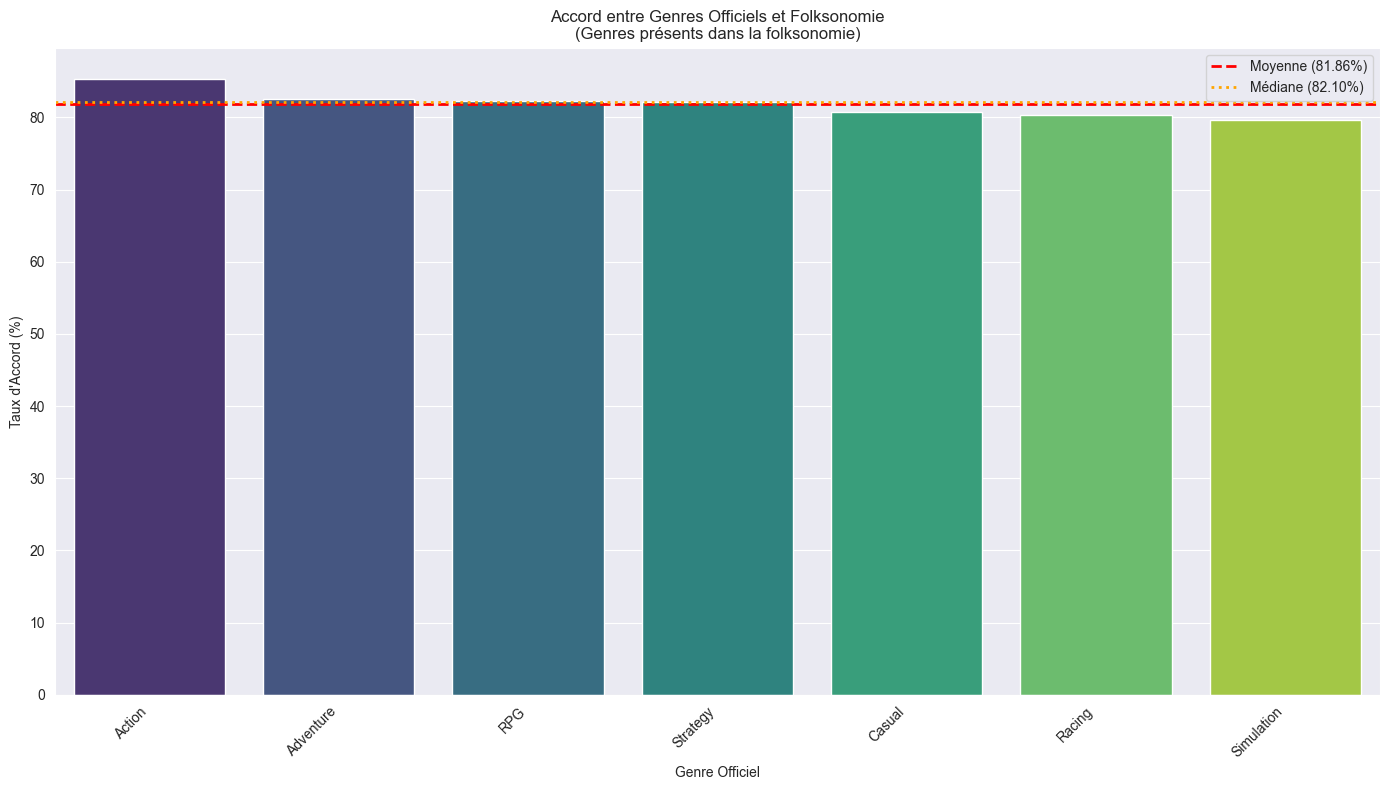



SECTION 2 : GENRES ABSENTS DE LA FOLKSONOMIE

Ces genres officiels n'existent pas dans la folksonomie (basée sur le gameplay).
Ils n'ont donc pas pu être analysés pour le consensus.

                Genre  Nombre de jeux (Experts)
                Indie                     79089
         Early Access                     12085
         Free To Play                      9757
               Sports                      4582
Massively Multiplayer                      3120
            Utilities                       931
Design & Illustration                       538
              Violent                       469
 Animation & Modeling                       437
            Education                       431
     Video Production                       313
     Game Development                       289
                 Gore                       285
    Software Training                       211
     Audio Production                       211
        Photo Editing                       148

In [10]:
# 1. Extraire les genres UNIQUES de la folksonomie
folk_genres_str = df_folk['Genre'].dropna().astype(str)
folk_genres_set = set()
for genres_str in folk_genres_str:
    # Chaque cellule peut contenir plusieurs genres séparés par des virgules
    genres_in_cell = [g.strip() for g in genres_str.split(',')]
    folk_genres_set.update(genres_in_cell)

print(f"Genres uniques présents dans la folksonomie : {len(folk_genres_set)}")

# 2. Obtenir tous les genres officiels uniques
all_expert_genres = set(df_expert_genres['expert_genre'].unique())

# 3. Séparer les genres : PRÉSENTS vs ABSENTS de la folksonomie
genres_in_both = all_expert_genres.intersection(folk_genres_set)
genres_absent_from_folk = all_expert_genres - folk_genres_set

# Préparation du croisement
common_ids = set(df_expert_genres['id']).intersection(set(df_folk['game_id']))

# ===== SECTION 1 : GENRES PRÉSENTS DANS LA FOLKSONOMIE =====
comparison_data = []

for genre in sorted(genres_in_both):
    # Jeux avec ce genre dans les experts
    expert_games = set(df_expert_genres[df_expert_genres['expert_genre'] == genre]['id'])

    if len(expert_games) == 0:
        continue

    # Jeux avec ce genre dans la folksonomie
    folk_games = set(df_folk[df_folk['Genre'].str.contains(genre, na=False)]['game_id'])

    # Calcul du consensus
    agreement = len(expert_games.intersection(folk_games)) / len(expert_games) * 100

    comparison_data.append({
        'Genre Officiel': genre,
        'Nombre de jeux (Experts)': len(expert_games),
        'Confirmés par Joueurs': len(expert_games.intersection(folk_games)),
        'Taux d\'Accord (%)': agreement
    })

# Créer le DataFrame de comparaison
df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values('Taux d\'Accord (%)', ascending=False)

print("\n" + "="*80)
print("SECTION 1 : GENRES PRÉSENTS DANS LA FOLKSONOMIE")
print("="*80 + "\n")
print(df_comparison.to_string(index=False))

# Calculer les statistiques
mean_agreement = df_comparison['Taux d\'Accord (%)'].mean()
median_agreement = df_comparison['Taux d\'Accord (%)'].median()
min_agreement = df_comparison['Taux d\'Accord (%)'].min()
max_agreement = df_comparison['Taux d\'Accord (%)'].max()
std_agreement = df_comparison['Taux d\'Accord (%)'].std()

print("\n" + "-"*80)
print("STATISTIQUES GLOBALES (genres présents dans la folksonomie)")
print("-"*80)
print(f"Nombre de genres analysés : {len(df_comparison)}")
print(f"Taux d'accord moyen : {mean_agreement:.2f}%")
print(f"Taux d'accord médian : {median_agreement:.2f}%")
print(f"Écart-type : {std_agreement:.2f}%")
print(f"Taux d'accord min : {min_agreement:.2f}% ({df_comparison.loc[df_comparison['Taux d\'Accord (%)'].idxmin(), 'Genre Officiel']})")
print(f"Taux d'accord max : {max_agreement:.2f}% ({df_comparison.loc[df_comparison['Taux d\'Accord (%)'].idxmax(), 'Genre Officiel']})")

# Visualisation des genres comparables
plt.figure(figsize=(14, 8))
sns.barplot(data=df_comparison, x='Genre Officiel', y='Taux d\'Accord (%)', hue='Genre Officiel', palette='viridis', legend=False)
plt.axhline(y=mean_agreement, color='red', linestyle='--', linewidth=2, label=f'Moyenne ({mean_agreement:.2f}%)')
plt.axhline(y=median_agreement, color='orange', linestyle=':', linewidth=2, label=f'Médiane ({median_agreement:.2f}%)')
plt.title("Accord entre Genres Officiels et Folksonomie\n(Genres présents dans la folksonomie)")
plt.xlabel("Genre Officiel")
plt.ylabel("Taux d'Accord (%)")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# ===== SECTION 2 : GENRES ABSENTS DE LA FOLKSONOMIE =====
if genres_absent_from_folk:
    print("\n\n" + "="*80)
    print("SECTION 2 : GENRES ABSENTS DE LA FOLKSONOMIE")
    print("="*80)
    print("\nCes genres officiels n'existent pas dans la folksonomie (basée sur le gameplay).")
    print("Ils n'ont donc pas pu être analysés pour le consensus.\n")

    absent_data = []
    for genre in sorted(genres_absent_from_folk):
        expert_count = len(set(df_expert_genres[df_expert_genres['expert_genre'] == genre]['id']))
        absent_data.append({
            'Genre': genre,
            'Nombre de jeux (Experts)': expert_count
        })

    df_absent = pd.DataFrame(absent_data).sort_values('Nombre de jeux (Experts)', ascending=False)
    print(df_absent.to_string(index=False))
    print(f"\nTotal jeux avec genres absents de la folksonomie : {df_absent['Nombre de jeux (Experts)'].sum()}")
else:
    print("\n\nTous les genres officiels sont présents dans la folksonomie !")

*Les genres officiels sont très majoritairement absents de la folksonomie, ce qui est conforme à la littérature (Lu et al. 2010). Cependant, les genres qui sont présents dans la folksonomie montrent un taux d'accord moyen de 80%, ce qui indique que les joueurs valident massivement les classifications officielles lorsqu'elles sont basées sur le gameplay.*

## 3. Le "Surplus Folksonomique" : Ce que les experts ne disent pas

Analysons les dimensions de notre taxonomie qui n'existent pratiquement pas dans les genres officiels (ex: Mécaniques, Mood).

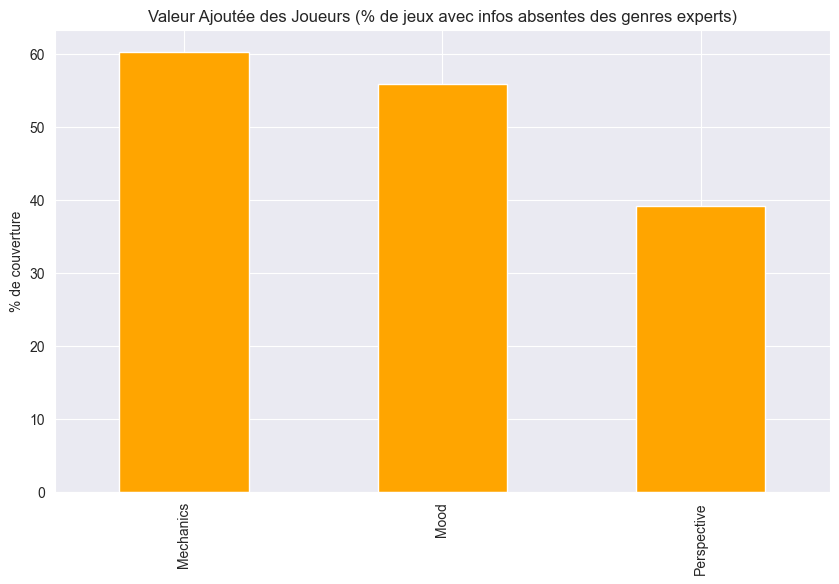

In [5]:
surplus = df_folk[['Mechanics', 'Mood', 'Perspective']].notna().mean() * 100

plt.figure(figsize=(10, 6))
surplus.plot(kind='bar', color='orange')
plt.title("Valeur Ajoutée des Joueurs (% de jeux avec infos absentes des genres experts)")
plt.ylabel("% de couverture")
plt.show()

## Conclusion de la comparaison

Conformément à la littérature (Lu et al. 2010) :

### Résultats clés :
1. **Analyse basée sur les genres folksonométriques uniquement** : Cette analyse ne porte que sur les genres qui existent réellement dans la folksonomie (99 genres de gameplay). Tous les genres officiels n'ayant pas d'équivalent dans la folksonomie ont été exclus, car ils n'auraient aucune base de comparaison valide.

2. **Validation des genres de gameplay** : Pour les genres présents dans les deux systèmes, on observe le degré de consensus entre experts (Steam) et foule (joueurs). Ce taux d'accord mesure si les joueurs valident ou enrichissent les classifications officielles.

3. **Granularité** : La folksonomie excelle là où les experts s'arrêtent. Les joueurs décrivent massivement les **Mécaniques** (Crafting, Permadeath) et l'**Ambiance** (Atmospheric, Dark), des données cruciales pour un système de recommandation ludologique.

4. **Complémentarité** : La base de données de gameplay structurée est donc un complément indispensable aux catégories marketing de Steam. Elle :
   - Valide certains genres officiels par le consensus de la foule
   - Ajoute des dimensions (Mécaniques, Mood) totalement absentes des genres officiels
   - Fournit une granularité bien supérieure

### Implication méthodologique :
Le taux d'accord moyen calculé porte **UNIQUEMENT sur les genres présents dans la folksonomie**.
Les genres absents de la folksonomie (marketing, distribution, statut de développement) ne sont pas analysés car ils
n'ont pas de correspondant valide dans le système folksonométrique basé sur le gameplay.
